# Module 4 — DFT Calculation for a semiconductor Solid: Silicon

**Learning objectives**
- Distinguish primitive cell, conventional cell, and supercell for a semiconductor
- Run a periodic SCF calculation with a sensible first-guess Ecut/k-mesh
- Converge total energy with respect to plane-wave cutoff and k-point mesh
- Visualize the Brillouin zone and its high-symmetry points
- Fit an equation of state to get the equilibrium lattice constant and bulk modulus
- Compute and interpret a band structure and projected density of states

## Setup: installing Quantum ESPRESSO

We install Quantum ESPRESSO (QE) the same way we did in the previous modules.

In [ ]:
!apt-get update -qq
!apt-get install -qq -y quantum-espresso
!pip install -q ase==3.23.0


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libfftw3-double3:amd64.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../libfftw3-double3_3.3.8-2ubuntu8_amd64.deb ...
Unpacking libfftw3-double3:amd64 (3.3.8-2ubuntu8) ...
Selecting previously unselected package quantum-espresso.
Preparing to unpack .../quantum-espresso_6.7-2build1_amd64.deb ...
Unpacking quantum-espresso (6.7-2build1) ...
Selecting previously unselected package quantum-espresso-data.
Preparing to unpack .../quantum-espresso-data_6.7-2build1_all.deb ...
Unpacking quantum-espresso-data (6.7-2build1) ...
Setting up quantum-espresso-data (6.7-2build1) ...
Setting up libfftw3-double3:amd64 (3.3.8-2ubuntu8) ...
Setting up quantum-espresso (6.7-2build1) ...
Processing triggers for libc-bin (2.35-0ubunt

In [ ]:
# Quick sanity check before going any further: confirm pw.x (a system
# binary from apt) and ase (a Python package from pip) are both reachable.
!which pw.x
!which projwfc.x
import ase
print('ase', ase.__version__, '->', ase.__file__)


/usr/bin/pw.x
/usr/bin/projwfc.x
ase 3.23.0 -> /usr/local/lib/python3.12/dist-packages/ase/__init__.py


In [ ]:
from ase.calculators.espresso import EspressoProfile
profile = EspressoProfile(command='pw.x', pseudo_dir='pseudo')


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ase.build import bulk
from ase.visualize.plot import plot_atoms
from ase.calculators.espresso import Espresso
from ase.eos import EquationOfState

plt.rcParams['figure.dpi'] = 110


### Getting pseudopotentials (GBRV library)

Quantum ESPRESSO needs a pseudopotential file (`.UPF`) for every element in the calculation. We use the **GBRV library** (Garrity, Bennett, Rabe & Vanderbilt, *Comput. Mater. Sci.* 81, 446 (2014)) — a comprehensive, well-tested pseudopotential set.

In [ ]:
# Download and unpack the GBRV pseudopotential library, then rename each
# file from GBRV's convention (e.g. 'o_pbe_v1.2.uspp.F.UPF') to the plain
# 'O.UPF' that ASE/QE expect. NOTE: keep this wget on a single line --
# splitting a quoted URL across a '!'-prefixed line with a trailing
# backslash does NOT reliably concatenate in Colab and silently breaks
# into two separate (broken) URLs.
!mkdir -p pseudo
!wget -q -O gbrv.tar.gz https://www.physics.rutgers.edu/gbrv/all_pbe_UPF_v1.5.tar.gz
!tar -xzf gbrv.tar.gz -C pseudo

import glob, os, shutil

for f in glob.glob('pseudo/*_*.UPF'):
    new_name = os.path.basename(f).split('_')[0].capitalize() + '.UPF'
    shutil.move(f, os.path.join('pseudo', new_name))

# We only actually need a few elements here: Si
print(sorted(glob.glob('pseudo/*.UPF'))[:10], '...')


['pseudo/Ag.UPF', 'pseudo/Al.UPF', 'pseudo/As.UPF', 'pseudo/Au.UPF', 'pseudo/B.UPF', 'pseudo/Ba.UPF', 'pseudo/Be.UPF', 'pseudo/Bi.UPF', 'pseudo/Br.UPF', 'pseudo/C.UPF'] ...


GBRV renames cleanly to `Element.UPF`.

In [ ]:
def pseudo_filename(symbol):
    return f'{symbol}.UPF'

def recommended_cutoffs(symbol):
    """GBRV is designed around one uniform cutoff rather than per-element
    values: ~40 Ry for ecutwfc, and since these are ultrasoft
    pseudopotentials, ecutrho should be 8-12x that (we use 8x)."""
    return 40, 320


In [ ]:
pseudopotentials = {'Si': pseudo_filename('Si')}
rec_ecutwfc, rec_ecutrho = recommended_cutoffs('Si')
print(f'GBRV recommends ecutwfc={rec_ecutwfc} Ry, ecutrho={rec_ecutrho} Ry as a starting point -- we will still verify this ourselves below.')


GBRV recommends ecutwfc=40 Ry, ecutrho=320 Ry as a starting point -- we will still verify this ourselves below.


## Part 0 — Primitive cell, conventional cell, supercell (quick recap)

Same pattern as Module 1, now specifically for Si (diamond-cubic).

Primitive cell:    2 atom(s)
Conventional cell: 8 atom(s)
2x2x2 supercell:   16 atom(s)


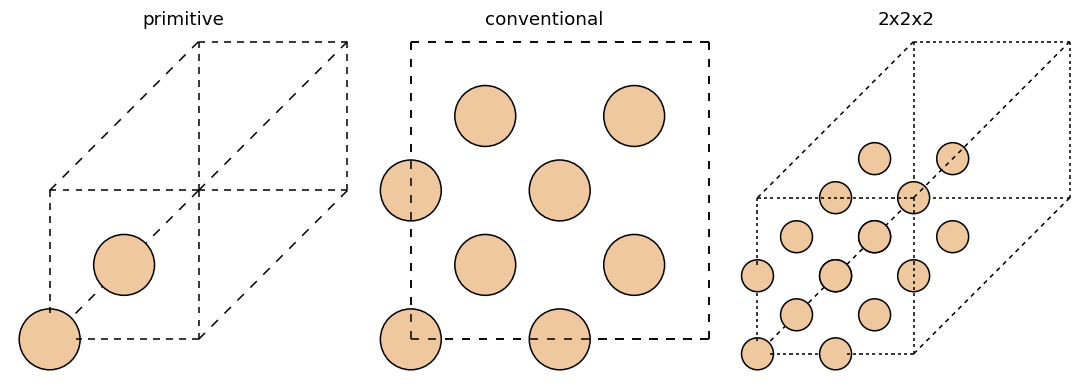

In [ ]:
prim = bulk('Si', 'diamond', a=5.43)
conv = bulk('Si', 'diamond', a=5.43, cubic=True)
sc222 = prim.repeat((2, 2, 2))

print(f'Primitive cell:    {len(prim)} atom(s)')
print(f'Conventional cell: {len(conv)} atom(s)')
print(f'2x2x2 supercell:   {len(sc222)} atom(s)')

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, (name, atoms) in zip(axes, [('primitive', prim), ('conventional', conv), ('2x2x2', sc222)]):
    plot_atoms(atoms, ax, radii=0.5, show_unit_cell=2)
    ax.set_title(name)
    ax.set_axis_off()
plt.tight_layout()
plt.show()


In [ ]:
from ase.visualize import view

# the 2x2x2 supercell
view(sc222, viewer='x3d')  # drag to rotate, scroll to zoom


Question: DFT calculations are generally performed using **primitive** cell for a bulk crystal, even though the conventional cell describes exactly the same infinite solid. Why?

## Part 1 — A single SCF run with a 'reasonable first guess'

Silicon is a **semiconductor**: at zero temperature its valence bands are completely full and conduction bands completely empty, so we can use simple `occupations='fixed'` — no smearing needed.

In [ ]:
input_data = {
    'control': {'calculation': 'scf', 'pseudo_dir': 'pseudo', 'outdir': 'out',
                'tprnfor': True, 'tstress': True},  # print forces & stress too
    'system': {
        'ecutwfc': 25,       # a REASONABLE starting guess -- we test this below
        'ecutrho': 200,
        'occupations': 'fixed',
    },
    'electrons': {'conv_thr': 1.0e-8},
}

atoms = bulk('Si', 'diamond', a=5.43)
atoms.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials, input_data=input_data,
                       kpts=(4, 4, 4))   # also just a starting guess
e0 = atoms.get_potential_energy()
print(f'Si: E = {e0:.4f} eV  ({e0/len(atoms):.4f} eV/atom)')


Si: E = -260.9462 eV  (-130.4731 eV/atom)


## Part 2 — Plane-wave cutoff (Ecut) convergence

In [ ]:
ecut_values = [15, 20, 25, 30, 35, 40, 45, 50]  # Ry
ecut_energies = []

for ecut in ecut_values:
    d = dict(input_data)
    d['system'] = dict(input_data['system'])
    d['system']['ecutwfc'] = ecut
    d['system']['ecutrho'] = 8 * ecut
    a = bulk('Si', 'diamond', a=5.43)
    a.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials, input_data=d, kpts=(4, 4, 4))
    ecut_energies.append(a.get_potential_energy() / len(a))
    print(f'ecutwfc = {ecut:>3} Ry   E = {ecut_energies[-1]:.5f} eV/atom')


ecutwfc =  15 Ry   E = -130.42497 eV/atom
ecutwfc =  20 Ry   E = -130.46844 eV/atom
ecutwfc =  25 Ry   E = -130.47309 eV/atom
ecutwfc =  30 Ry   E = -130.47327 eV/atom
ecutwfc =  35 Ry   E = -130.47380 eV/atom
ecutwfc =  40 Ry   E = -130.47406 eV/atom
ecutwfc =  45 Ry   E = -130.47399 eV/atom
ecutwfc =  50 Ry   E = -130.47398 eV/atom


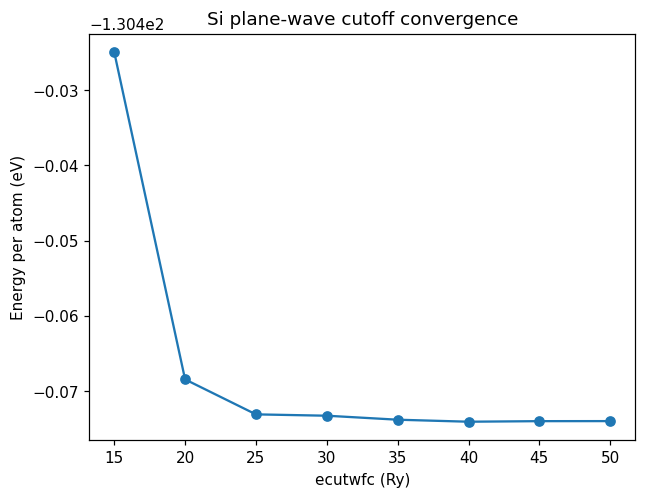

In [ ]:
plt.plot(ecut_values, ecut_energies, 'o-')
plt.xlabel('ecutwfc (Ry)')
plt.ylabel('Energy per atom (eV)')
plt.title('Si plane-wave cutoff convergence')
plt.show()

# Pick a converged cutoff: e.g. the smallest ecut whose energy is within
# 1 meV/atom of the highest-ecut result.
converged_ecutwfc = 35  # <-- read this off the plot


## Part 3 — k-point convergence, and visualizing the Brillouin zone

In [ ]:
kgrids = [2, 3, 4, 5, 6, 8, 10, 12, 14]
kpt_energies = []

for n in kgrids:
    d = dict(input_data)
    d['system'] = dict(input_data['system'])
    d['system']['ecutwfc'] = converged_ecutwfc
    d['system']['ecutrho'] = 8 * converged_ecutwfc
    a = bulk('Si', 'diamond', a=5.43)
    a.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials, input_data=d, kpts=(n, n, n))
    kpt_energies.append(a.get_potential_energy() / len(a))
    print(f'{n}x{n}x{n} k-mesh   E = {kpt_energies[-1]:.5f} eV/atom')


2x2x2 k-mesh   E = -129.29151 eV/atom
3x3x3 k-mesh   E = -130.25900 eV/atom
4x4x4 k-mesh   E = -130.47380 eV/atom
5x5x5 k-mesh   E = -130.53549 eV/atom
6x6x6 k-mesh   E = -130.55571 eV/atom
8x8x8 k-mesh   E = -130.56572 eV/atom
10x10x10 k-mesh   E = -130.56730 eV/atom
12x12x12 k-mesh   E = -130.56758 eV/atom
14x14x14 k-mesh   E = -130.56764 eV/atom


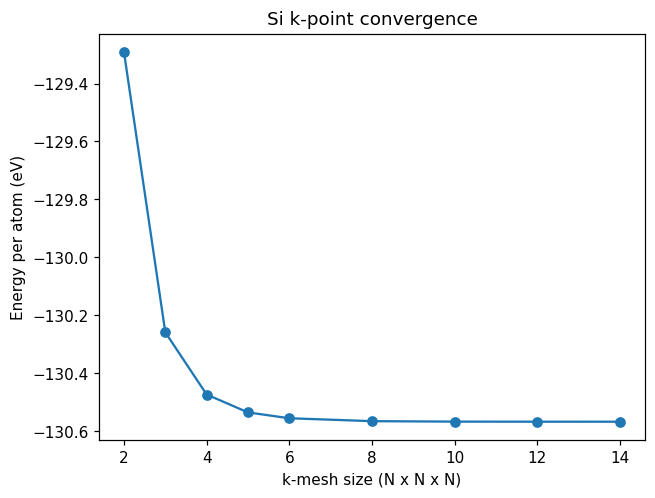

In [ ]:
plt.plot(kgrids, kpt_energies, 'o-')
plt.xlabel('k-mesh size (N x N x N)')
plt.ylabel('Energy per atom (eV)')
plt.title('Si k-point convergence')
plt.show()

converged_kpts = 8  # <-- read this off the plot


FCC(a=5.43)
  Variant name: FCC
  Special point names: GKLUWX
  Default path: GXWKGLUWLK,UX

  Special point coordinates:
    G   0.0000  0.0000  0.0000
    K   0.3750  0.3750  0.7500
    L   0.5000  0.5000  0.5000
    U   0.6250  0.2500  0.6250
    W   0.5000  0.2500  0.7500
    X   0.5000  0.0000  0.5000



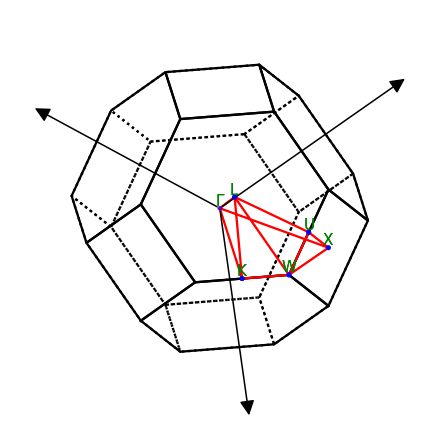

<Axes3D: >

In [ ]:
# Visualize the Brillouin zone itself, with high-symmetry points labeled,
# so 'k-point density' stops being an abstract number.
prim = bulk('Si', 'diamond', a=5.43)
lat = prim.cell.get_bravais_lattice()
print(lat.description())
lat.plot_bz(show=True)


## Part 4 — Equation of state: lattice constant and bulk modulus

We scan the lattice constant around our starting guess, compute the energy at each volume with our now-converged Ecut/k-mesh, and fit an equation of state.

### Fitting the equation of state

Rather than hand-rolling a polynomial fit, we use ASE's built-in `EquationOfState` class, which fits a Birch–Murnaghan equation of state to `(volume, energy)` pairs and returns the equilibrium volume $V_0$, energy $E_0$, and **bulk modulus $B_0$** directly.

In [ ]:
scale_factors = np.linspace(0.94, 1.06, 7)
volumes, eos_energies = [], []

d = dict(input_data)
d['system'] = dict(input_data['system'])
d['system']['ecutwfc'] = converged_ecutwfc
d['system']['ecutrho'] = 8 * converged_ecutwfc

for s in scale_factors:
    a = bulk('Si', 'diamond', a=5.43 * s)
    a.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials, input_data=d,
                       kpts=(converged_kpts, converged_kpts, converged_kpts))
    volumes.append(a.get_volume())
    eos_energies.append(a.get_potential_energy())
    print(f'a scale = {s:.3f}   V = {volumes[-1]:.2f} A^3   E = {eos_energies[-1]:.4f} eV')


a scale = 0.940   V = 33.24 A^3   E = -260.5737 eV
a scale = 0.960   V = 35.41 A^3   E = -260.8773 eV
a scale = 0.980   V = 37.67 A^3   E = -261.0564 eV
a scale = 1.000   V = 40.03 A^3   E = -261.1314 eV
a scale = 1.020   V = 42.48 A^3   E = -261.1201 eV
a scale = 1.040   V = 45.02 A^3   E = -261.0381 eV
a scale = 1.060   V = 47.67 A^3   E = -260.8989 eV


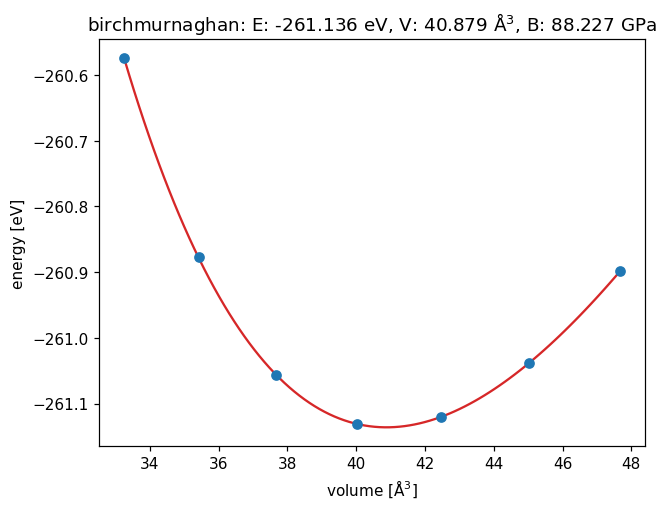

Equilibrium volume: 40.88 A^3, Lattice para: 5.47 A per primitive cell
Bulk modulus B0: 88.2 GPa


In [ ]:
eos = EquationOfState(volumes, eos_energies, eos='birchmurnaghan')
v0, e0, B = eos.fit()
a0 = (v0 * 4) ** (1 / 3)   # diamond-cubic: 8 atoms per conventional cell, 2 per primitive
B_GPa = B / 6.242e-3   # eV/A^3 -> GPa

eos.plot()
plt.show()
print(f'Equilibrium volume: {v0:.2f} A^3, Lattice para: {a0:.2f} A per primitive cell')
print(f'Bulk modulus B0: {B_GPa:.1f} GPa')


Question: Look up the experimental lattice constant and bulk modulus of Si. Does you computed data match to that of the experimental value? What are the most likely causes of deviations?

## Part 5 — Band structure and projected density of states

Band structures are computed **non-self-consistently**: first an SCF run converges the electron density, then a second run reuses that density and just diagonalizes the Hamiltonian along a path of high-symmetry k-points through the Brillouin zone.

In [ ]:
a_eq = bulk('Si', 'diamond', a=a0)

# Step 1: SCF at the equilibrium geometry, to get a converged density
scf_data = dict(input_data)
scf_data['control'] = dict(input_data['control'])
scf_data['system'] = dict(input_data['system'])
scf_data['system']['ecutwfc'] = converged_ecutwfc
scf_data['system']['ecutrho'] = 8 * converged_ecutwfc
a_eq.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials, input_data=scf_data,
                      kpts=(converged_kpts, converged_kpts, converged_kpts))
a_eq.get_potential_energy()


-261.1364688477955

In [ ]:
# Step 2: a band path through the standard high-symmetry points for this
# Bravais lattice, then a non-self-consistent 'bands' run along it.
path = a_eq.cell.bandpath(npoints=250)
print(path)  # shows which special points ASE picked for this lattice, e.g. G, X, W, K, L

bands_data = dict(scf_data)
bands_data['control'] = dict(scf_data['control'])
bands_data['control']['calculation'] = 'bands'
bands_data['control']['verbosity'] = 'high'   # <-- pw.x won't print eigenvalues for this many k-points otherwise
bands_data['system'] = dict(scf_data['system'])
bands_data['system']['nbnd'] = 8   # <-- WITHOUT this, QE only computes the 4 occupied
                                    #     bands and there is no conduction band to see at all

a_bands = bulk('Si', 'diamond', a=a0)
a_bands.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials,
                         input_data=bands_data, kpts=path)

results_bands = a_bands.get_properties(['eigenvalues'])


BandPath(path='GXWKGLUWLK,UX', cell=[3x3], special_points={GKLUWX}, kpts=[250x3])


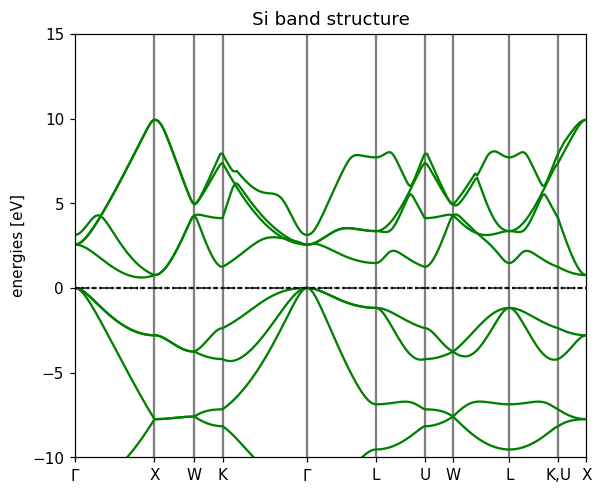

In [ ]:
from ase.spectrum.band_structure import BandStructure
bs = BandStructure(
    path=path,
    energies=results_bands['eigenvalues'],
    reference=a_eq.calc.get_fermi_level(),
)

bs = bs.subtract_reference()

fig, ax = plt.subplots(figsize=(6, 5))
bs.plot(ax=ax, emin=-10, emax=15)
ax.axhline(0, color='k', linestyle='--', linewidth=1)  # mark E_Fermi explicitly
ax.set_title('Si band structure')
plt.show()


Question: Locate the Fermi level on your band diagram. Locate the valence band maximum (VBM) and conduction band minimum (CBM). Are they at the *same* k-point or different ones? What does that tell you about how Si absorbs or emits light, compared to a 'direct-gap' material where VBM and CBM line up?

### Measuring the bandgap

Lets quantify direct vs. indirect precisely.

In [ ]:
energies = bs.energies[0]        # shape (n_kpoints, n_bands), already Fermi-shifted
n_occ = 4                        # Si: 2 atoms x 4 valence electrons / 2 per band

valence_band = energies[:, n_occ - 1]   # top occupied band, across the whole path
conduction_band = energies[:, n_occ]    # first empty band, across the whole path

vbm = valence_band.max()
cbm = conduction_band.min()
indirect_gap = cbm - vbm

k_at_vbm = valence_band.argmax()
direct_gap_at_vbm = conduction_band[k_at_vbm] - valence_band[k_at_vbm]
gap_at_gamma = conduction_band[0] - valence_band[0]   # our path starts at Gamma

print(f'True (indirect) gap, VBM and CBM at different k-points: {indirect_gap:.3f} eV')
print(f'Gap measured only at the k-point where the VBM sits:    {direct_gap_at_vbm:.3f} eV')
print(f'Gap measured only at Gamma:                             {gap_at_gamma:.3f} eV')
print(f'Experimental Si gap (indirect, ~300 K): ~1.12 eV')


True (indirect) gap, VBM and CBM at different k-points: 0.614 eV
Gap measured only at the k-point where the VBM sits:    2.557 eV
Gap measured only at Gamma:                             2.557 eV
Experimental Si gap (indirect, ~300 K): ~1.12 eV


Question: **A well-known DFT limitation:** the semi-local exchange-correlation functionals used in this course (and in the vast majority of routine DFT calculations) are known to systematically **underestimate band gaps** — often by 30-50% or more for semiconductors. This is a limitation of the xc approximation itself. Compare your computed gap above to the ~1.12 eV experimental value.

In [ ]:
# Projected (orbital-resolved) density of states, via QE's projwfc.x.
# We run a denser non-self-consistent (nscf) calculation first, then
# project the wavefunctions onto atomic orbitals.
nscf_data = dict(scf_data)
nscf_data['control'] = dict(scf_data['control'])
nscf_data['control']['calculation'] = 'nscf'
nscf_data['system'] = dict(scf_data['system'])
nscf_data['system']['nosym'] = True


a_nscf = bulk('Si', 'diamond', a=a0)
a_nscf.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials,
                        input_data=nscf_data, kpts=(12, 12, 12))

from ase.calculators.calculator import PropertyNotImplementedError, PropertyNotPresent

try:
    a_nscf.get_properties(['eigenvalues'])
except (PropertyNotImplementedError, PropertyNotPresent):
    pass


In [ ]:
# projwfc.x reads the nscf run's output directory (same outdir/prefix)
# and writes one file per (atom, orbital).
projwfc_input = (
    "&PROJWFC\n"
    "  outdir='out',\n"
    "  prefix='pwscf',\n"
    "  filpdos='si_pdos',\n"
    "  degauss=0.02,\n"
    "  DeltaE=0.05,\n"
    "/\n"
)
with open('projwfc.in', 'w') as f:
    f.write(projwfc_input)
!projwfc.x -in projwfc.in > projwfc.out
!ls *pdos*


'si_pdos.pdos_atm#1(Si)_wfc#1(s)'  'si_pdos.pdos_atm#2(Si)_wfc#2(p)'
'si_pdos.pdos_atm#1(Si)_wfc#2(p)'   si_pdos.pdos_tot
'si_pdos.pdos_atm#2(Si)_wfc#1(s)'


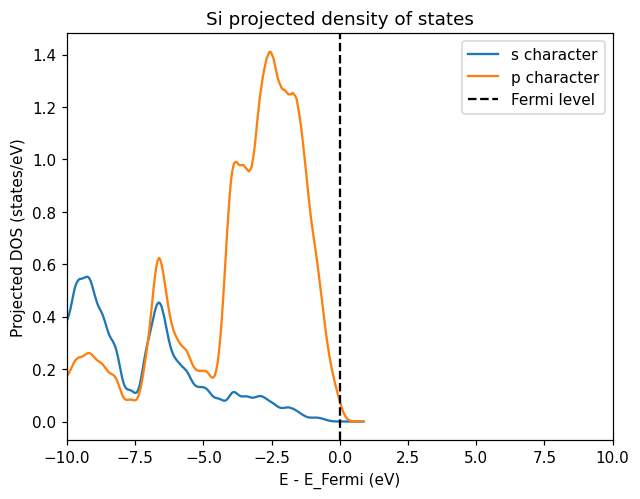

In [ ]:
import glob

fermi = a_eq.calc.get_fermi_level()

def read_pdos_file(fname):
    """QE pdos files: col 0 = energy (eV), col 1 = ldos, cols 2.. = per-m pdos."""
    data = np.loadtxt(fname, comments='#')
    energy = data[:, 0] - fermi
    pdos = data[:, 2:].sum(axis=1)  # sum over m to get the orbital's total pdos
    return energy, pdos

s_files = glob.glob('si_pdos.pdos_atm*wfc*(s)')
p_files = glob.glob('si_pdos.pdos_atm*wfc*(p)')

energy = None
s_pdos = p_pdos = None
for fn in s_files:
    en, pd = read_pdos_file(fn)
    energy = en
    s_pdos = pd if s_pdos is None else s_pdos + pd
for fn in p_files:
    en, pd = read_pdos_file(fn)
    p_pdos = pd if p_pdos is None else p_pdos + pd

plt.plot(energy, s_pdos, label='s character')
if p_pdos is not None:
    plt.plot(energy, p_pdos, label='p character')
plt.axvline(0, color='k', linestyle='--', label='Fermi level')
plt.xlabel('E - E_Fermi (eV)')
plt.ylabel('Projected DOS (states/eV)')
plt.title('Si projected density of states')
plt.legend()
plt.xlim(-10, 10)
plt.show()


Question: Which orbital character (s or p) dominates near the Fermi level for Si? Justify your observation.

Question: Compare this k-point convergence behavior to Aluminum's from Module 3: does Si need a finer or coarser mesh to reach the same precision? Justify your observation.

## Part 6 — Comparing energies of different phases

Lets evaluate Si in a couple of *other*, purely hypothetical crystal structures, using exactly the same E-vs-volume approach as Part 4, and see whether the energetics pick out diamond-cubic as lowest energy structure.

In [ ]:
# Same recipe as Part 4's EOS scan, just repeated for three different
# structure types built from the same element. The lattice-constant
# guesses are chosen so all three start out around a similar volume per
# atom (~20 A^3), so their curves actually overlap enough to compare.
phase_structures = {
    'diamond': ('diamond', 5.43),
    'FCC':     ('fcc', 4.31),
    'BCC':     ('bcc', 3.42),
}

phase_input_data = dict(input_data)
phase_input_data['system'] = dict(input_data['system'])
phase_input_data['system']['ecutwfc'] = converged_ecutwfc
phase_input_data['system']['ecutrho'] = 8 * converged_ecutwfc

phase_data = {}   # name -> (volumes_per_atom, energies_per_atom)

for name, (structure_type, a_guess) in phase_structures.items():
    scales = np.linspace(0.88, 1.12, 7)
    vols, energies = [], []
    for s in scales:
        a = bulk('Si', structure_type, a=a_guess * s)
        a.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials,
                           input_data=phase_input_data,
                           kpts=(converged_kpts, converged_kpts, converged_kpts))
        vols.append(a.get_volume() / len(a))
        energies.append(a.get_potential_energy() / len(a))
    phase_data[name] = (vols, energies)
    print(f'{name}: done')


diamond: done
FCC: done
BCC: done


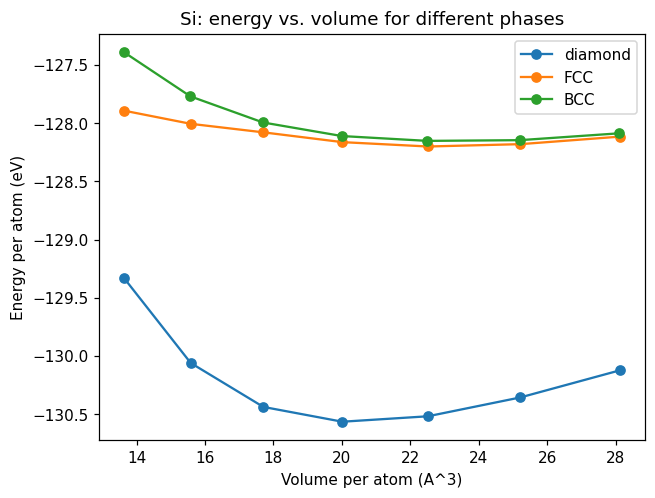

DFT predicts diamond has the lowest minimum energy per atom.


In [ ]:
fig, ax = plt.subplots()
for name, (vols, energies) in phase_data.items():
    ax.plot(vols, energies, 'o-', label=name)
ax.set_xlabel('Volume per atom (A^3)')
ax.set_ylabel('Energy per atom (eV)')
ax.set_title('Si: energy vs. volume for different phases')
ax.legend()
plt.show()

lowest = min(phase_data, key=lambda name: min(phase_data[name][1]))
print(f'DFT predicts {lowest} has the lowest minimum energy per atom.')


### Phase transition pressure via common tangent construction

In [ ]:
def lower_hull(points):
    """Andrew's monotone-chain algorithm, keeping only the LOWER hull
    (same function as Module 5)."""
    pts = sorted(set(points))
    lower = []
    for p in pts:
        while len(lower) >= 2:
            (x1, y1), (x2, y2) = lower[-2], lower[-1]
            cross = (x2 - x1) * (p[1] - y1) - (y2 - y1) * (p[0] - x1)
            if cross <= 0:
                lower.pop()
            else:
                break
        lower.append(p)
    return lower


def transition_pressure(phase_data, name_A, name_B):
    """Combine two phases' (V, E) points, take the lower convex hull, and
    look for the hull segment that connects a point from phase A directly
    to a point from phase B. That segment's slope is dE/dV = -P at the
    predicted transition. Returns the pressure in GPa, or None if the
    two phases don't actually cross within the volumes you sampled --
    which is a perfectly legitimate outcome, not an error, and tells you
    one phase simply dominates throughout this range."""
    tagged = ([(v, e, name_A) for v, e in zip(*phase_data[name_A])]
              + [(v, e, name_B) for v, e in zip(*phase_data[name_B])])
    tagged.sort()
    hull = lower_hull([(v, e) for v, e, _ in tagged])
    lookup = {(v, e): label for v, e, label in tagged}
    hull_labels = [lookup[(v, e)] for v, e in hull]

    for i in range(len(hull) - 1):
        if hull_labels[i] != hull_labels[i + 1]:
            (v1, e1), (v2, e2) = hull[i], hull[i + 1]
            if abs(v2 - v1) < 0.05:
                # Two near-identical volumes from different phases landing next
                # to each other on the hull is a numerical artifact, not a real
                # tangent -- skip it and keep looking for a genuine crossing.
                continue
            slope = (e2 - e1) / (v2 - v1)     # eV / A^3
            P_transition = -slope * 160.2      # eV/A^3 -> GPa
            print(f'Common-tangent segment found between {hull_labels[i]} '
                  f'and {hull_labels[i + 1]}')
            print(f'Estimated transition pressure: {P_transition:.1f} GPa')
            return P_transition
    print(f'No well-resolved {name_A}-{name_B} common-tangent segment found -- '
          f'one phase is likely lower in energy everywhere in this volume range.')
    return None


transition_pressure(phase_data, 'diamond', 'BCC')


No well-resolved diamond-BCC common-tangent segment found -- one phase is likely lower in energy everywhere in this volume range.


Question: Real Si transitions from diamond to β-tin around 11-12 GPa experimentally. Include energetics of β-tin structure of Si in the above plot and try to estimate the transformation P between the two phases?

## Discuss / Explain

Answer all the "Questions" include above in this notebook.

## Assignment Exercises

Repeat the full workflow (convergence, EOS, band structure, quantitative gap) for the below materials, and compare the nature of bandgap.

1. **Germanium** — same diamond-cubic structure family as Si (`bulk('Ge', 'diamond', a=5.66)`), also an indirect-gap semiconductor, but with a *much* smaller experimental gap (~0.67 eV). How is Ge bandgap compared to that of Si?
2. **GaAs** — a **direct-gap** semiconductor (zincblende structure, two elements: `bulk('GaAs', 'zincblende', a=5.65)`, needs pseudopotentials for both Ga and As). Run the same quantitative VBM/CBM analysis you used for Si. Does the direct-gap character show up clearly in your numbers?
3. **Diamond (C)** — same structure family again, but a wide-gap insulator (~5.5 eV experimental) rather than a semiconductor. How far off is your DFT-computed gap this time, in absolute eV and in percentage terms, compared to Si's underestimate?


## Summary

You've now run a complete periodic DFT workflow on Si: convergence testing, an equation of state, a band structure, and a projected DOS.

## References

- Giannozzi, P. et al. *QUANTUM ESPRESSO: a modular and open-source software project for quantum simulations of materials*. J. Phys.: Condens. Matter 21, 395502 (2009); and later updates (2017, 2020). https://www.quantum-espresso.org
- Larsen, A. H. et al. *The Atomic Simulation Environment — a Python library for working with atoms*. J. Phys.: Condens. Matter 29, 273002 (2017). https://wiki.fysik.dtu.dk/ase/
- Garrity, K. F., Bennett, J. W., Rabe, K. M. & Vanderbilt, D. *Pseudopotentials for high-throughput DFT calculations*. Comput. Mater. Sci. 81, 446 (2014). https://www.physics.rutgers.edu/gbrv/
